In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from time import perf_counter

In [50]:
# Implement baseline algorithm

def baseline_max_sublist(arr):
    n = len(arr)
    max_so_far = -999999999999999
    for i in range(0,n):
        sum = 0
        for j in range(i,n):
            sum = arr[j] + sum
            if sum > max_so_far: 
                max_so_far = sum
    return max_so_far

arr = [-2, 1, -3, 4, -1, 2, 1, -5, 4]
print(baseline_max_sublist(arr))

6


In [51]:
# Implement target algorithm

def kadane_max_sublist(arr):
    n = len(arr)
    max_so_far = -999999999999999
    current_max = 0
    for i in range(0,n):
        current_max = current_max + arr[i]
        if current_max > max_so_far:
            max_so_far = current_max
        elif current_max < 0:
            current_max = 0
    return max_so_far

arr = [-2, 1, -3, 4, -1, 2, 1, -5, 4]
print(kadane_max_sublist(arr))

6


[-67, -15, 24, 36, -21]
baseline:[(100, 0.0001618899999812129), (500, 0.004452100000162318), (1000, 0.018371770000339894), (2500, 0.11570079000011901), (5000, 0.4598888699998497), (10000, 1.8281624600000215)]
kadane:[(100, 4.490000355872325e-06), (500, 2.010000025620684e-05), (1000, 4.2490000123507346e-05), (2500, 0.00010816000030899886), (5000, 0.0002201999999670079), (10000, 0.0004370900001958944)]


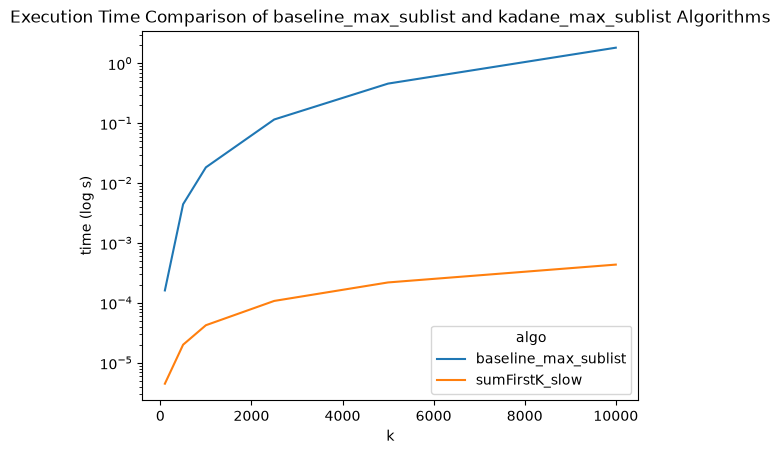

In [ ]:
# helper function

def helper_function(n):
    random_array = []
    for i in range(n):
        random_array.append(np.random.randint(-100, 101))
    return random_array

print(helper_function(5))

# generates random lists of integers for testing
def test_cases(n):
    test_list = []
    for i in n:
        test_list.append(helper_function(i))
    return test_list

test_list = test_cases([100, 500, 1000, 2500, 5000, 10000])

# Function to benchmark the execution time of a given algorithm over a set of test cases

def benchmark_algo_multi(algo, test_cases, repeat=1):
    times = []
    for i in test_cases:
        total_duration = 0
        for _ in range(repeat):
            start = perf_counter()
            algo(i)
            end = perf_counter()
            duration = end - start
            total_duration += duration
        avg_time = total_duration / repeat
        times.append((len(i), avg_time))
    return times

baseline_max_sublist_times = benchmark_algo_multi(baseline_max_sublist, test_list, repeat=10)
kadane_max_sublist_times = benchmark_algo_multi(kadane_max_sublist, test_list, repeat=10)

print(f"baseline:{baseline_max_sublist_times}")
print(f"kadane:{kadane_max_sublist_times}")

df_base = pd.DataFrame(baseline_max_sublist_times, columns = ["k", "time"])
df_base['algo'] = "baseline_max_sublist"

df_kadane = pd.DataFrame(kadane_max_sublist_times, columns = ["k", "time"])
df_kadane['algo'] = "sumFirstK_slow"

df = pd.concat([df_base, df_kadane], ignore_index=True)

sns.lineplot(data=df, x="k", y="time", hue="algo")
plt.xlabel("k")
plt.ylabel("time (log s)")
plt.title("Execution Time Comparison of baseline_max_sublist and kadane_max_sublist Algorithms")
plt.yscale("log")
plt.show()
